In [1]:
from itertools import cycle
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import os

import torch
from torch.utils.data import DataLoader
from diffusers import AutoencoderKL, AutoencoderKLFlux2
from transformers import get_cosine_schedule_with_warmup

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils import show_batch_grid, get_number_of_parameters, prepare_noise
from custom_datasets.pokemon_dataset import PokemonDataset
from models.LightningDiT import LightningDiT
from models.feature_encoder import MultiScaleFeatureEncoder
from models.advanced_deature_encoder import FeatureExtractor, MAEResNet
from drifting import (
    drifting_loss_multifeatures
)

In [3]:
DEVICE = "cuda:0"
IMG_SIZE = 128

In [4]:
# dataset_path = "/home/msst/repo/drifting/data/HumanFacesDataset/gen/"
# dataset_type = "FACES"

# # dataset_path = "/home/msst/repo/drifting/data/pokemon/images"
# # dataset_type = "POKEMON"

dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "FACES"

pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE, dataset_type=dataset_type)

Number of images: 202599


In [5]:
# vae =  AutoencoderKL.from_pretrained(
#     "./models/sd-vae-ft-mse",
#     device_map="cuda",
#     torch_dtype=torch.bfloat16
# ).eval()
# LATENT_SIZE = IMG_SIZE // 8
# LATENT_CHANNELS = 4

# feature_encoder_path = "/home/msst/repo/drifting/checkpoints/MAE_sd-vae/CelebA/transformer_28epochs.pth"

# print("VAE:")
# get_number_of_parameters(vae)


vae =  AutoencoderKLFlux2.from_pretrained(
    "./models/flux_vae",
    device_map="cuda",
    torch_dtype=torch.bfloat16
).eval()
LATENT_SIZE = IMG_SIZE // 8
LATENT_CHANNELS = 32

feature_encoder_path = "/home/msst/repo/drifting/checkpoints/MAE_flux_vae/CelebA/transformer_61epochs.pth"

print("VAE:")
get_number_of_parameters(vae)

VAE:
Params: 84M


In [6]:
# dataloader = DataLoader(pokemon_dataset, batch_size=64, shuffle=True, num_workers=8)

# batch = next(iter(dataloader))
# show_batch_grid(batch, n=4, figsize=(3, 3), denormalize=True)

# with torch.no_grad():
#     recon = vae(batch.cuda())["sample"]
# show_batch_grid(recon, n=4, figsize=(3, 3), denormalize=True)

In [7]:
# with torch.no_grad():
#     latent = vae.encode(batch.cuda()).latent_dist.mode()

#     reco_latent = vae.decode(latent).sample

# show_batch_grid(reco_latent, n=4, figsize=(3, 3), denormalize=True)

In [8]:
transformer = LightningDiT(
    input_size=LATENT_SIZE,
    patch_size=2,
    in_channels=LATENT_CHANNELS,
    hidden_size=768,
    depth=12,
    num_heads=12,
    use_qknorm=True,
    use_swiglu=True,
    use_rope=True,
    use_rmsnorm=True,
    use_checkpointing=False,
).to(torch.bfloat16).to(DEVICE)


print("ViT:")
get_number_of_parameters(transformer)

opt = torch.optim.AdamW(
    transformer.parameters(), 
    lr=2e-4, 
    betas=(0.9, 0.95),
    weight_decay=0.02,
    # lr=1e-5, 
    # betas=(0.9, 0.99),
    # weight_decay=0.01
)

ViT:
Params: 85.3M


In [9]:
# transformer.load_state_dict(
#     torch.load(
#         "/home/msst/repo/drifting/checkpoints/CelebA_15072026_ps2_flux-vae/transformer_step50000.pth"
#         )
#     )

In [10]:
# feature_encoder = MultiScaleFeatureEncoder(
#     model_name='resnet50',
#     freeze=True
# ).to(torch.bfloat16).to(DEVICE).eval()

# print("Feature encoder:")
# get_number_of_parameters(feature_encoder)

# # feature_encoder = torch.compile(feature_encoder)

# mae_resnet = MAEResNet(
#         in_channels = 3,
#         base_channels = 256,
#         mask_patch_size = 2,
#         input_patch_size = 8,
#         layers = (3, 4, 6, 3),
#     )
# mae_resnet.load_state_dict(torch.load("/home/msst/repo/drifting/checkpoints/MAE/CelebA/transformer_34epochs.pth"))

# feature_encoder = FeatureExtractor(
#     encoder=mae_resnet.encoder.to(torch.bfloat16).cuda(),
#     input_patch_size=mae_resnet.input_patch_size,
#     every_k_block=None
# )

# print("Feature encoder:")
# get_number_of_parameters(feature_encoder)

mae_resnet = MAEResNet(
        in_channels = LATENT_CHANNELS,
        base_channels = 256,
        mask_patch_size = 2,
        input_patch_size = 1,
        layers = (3, 4, 6, 3),
    )
mae_resnet.load_state_dict(torch.load(feature_encoder_path))

feature_encoder = FeatureExtractor(
    encoder=mae_resnet.encoder.to(torch.bfloat16).cuda(),
    input_patch_size=mae_resnet.input_patch_size,
    every_k_block=2
)

print("Feature encoder:")
get_number_of_parameters(feature_encoder)

Feature encoder:
Params: 340M


In [11]:
def train_drifting_with_vae(
        vae,
        transformer,
        opt,
        T_list=[0.02, 0.05, 0.2],
        batch_size=64,
        gradient_accumulation=1,
        training_steps=10000,
        plot_every=250,
        seed=None,
        save_step=5000,
        loss_scaling=1.0,
        save_path="checkpoints/",
    ):
    """Train drifting model. Returns model and loss history."""
    if seed is not None:
        torch.manual_seed(seed)
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer=opt,
        num_warmup_steps=min(64, training_steps // gradient_accumulation),
        num_training_steps=training_steps // gradient_accumulation,
    )

    dataloader = cycle(DataLoader(
        pokemon_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        drop_last=True
    ))

    loss_history = []
    plot_loss_acc = []
    ema = None
    pbar = tqdm(range(1, training_steps + 1))
    
    for step in pbar:
        pos = next(dataloader).to(DEVICE)

        with torch.no_grad():
            # pos_features = feature_encoder(pos)
            pos_latent = vae.encode(pos).latent_dist.sample()
            pos_features = feature_encoder(pos_latent)

        noise = torch.randn(batch_size, LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE, device=DEVICE, dtype=pos.dtype)        
        
        with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
            gen_latent = transformer(noise)
            # gen = vae.decode(gen_latent).sample
            # gen_features = feature_encoder(gen)
            gen_features = feature_encoder(gen_latent)

        loss = drifting_loss_multifeatures(
            x_features=gen_features,
            y_pos_features=pos_features,
            T_list=T_list,
        )
        loss = loss * loss_scaling

        loss.backward()
        if step % gradient_accumulation == 0:
            opt.step()
            scheduler.step()
            opt.zero_grad()


        plot_loss_acc.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        pbar.set_postfix(loss=f"{ema:.2e}")

        if step % plot_every == 0 or step == 1:
            with torch.no_grad():
                noise = torch.randn(18, LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE, device=DEVICE, dtype=pos.dtype)
                gen_latent = transformer(noise)
                gen = vae.decode(gen_latent).sample
    
                clear_output(wait=True)
                show_batch_grid(gen, n=6, figsize=(9, 9), denormalize=True)
    
                loss_history.append(sum(plot_loss_acc) / len(plot_loss_acc))
                plot_loss_acc = []
                # plt.plot(loss_history)
                plt.semilogy(loss_history)
                plt.show()
            

        if (step+1) % save_step == 0:
            os.makedirs(save_path, exist_ok=True)
            torch.save(transformer.state_dict(), f"{save_path}/transformer_step{step+1}.pth")


    return loss_history

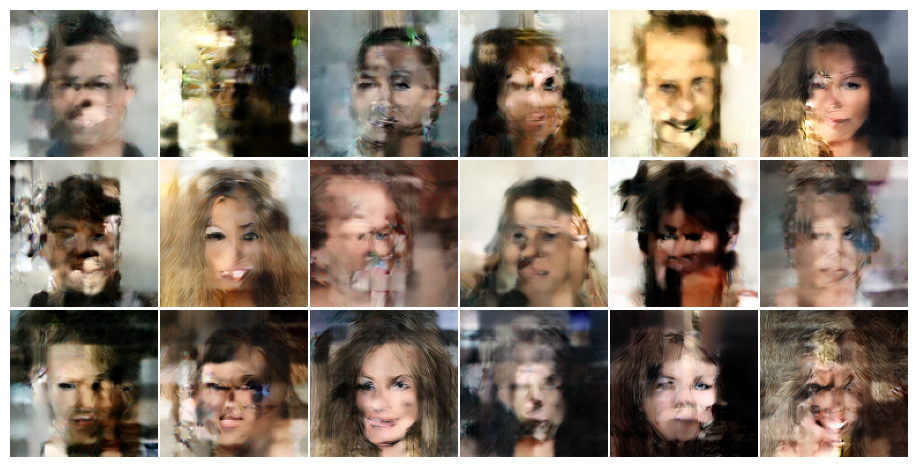

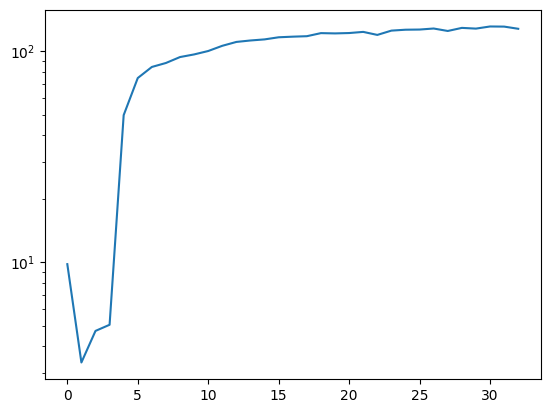

  7%|▋         | 3274/50000 [26:32<6:18:47,  2.06it/s, loss=1.29e+02]


KeyboardInterrupt: 

In [12]:
loss_history = train_drifting_with_vae(
    vae,
    transformer,
    opt,
    T_list=[0.02, 0.05, 0.2],
    batch_size=128,
    gradient_accumulation=1,
    training_steps=50000,
    plot_every=100,
    seed=None,
    loss_scaling=1.0e9,
    save_step=2500,
    save_path="checkpoints/CelebA_19072026_ps2_flux-vae",
)

In [ ]:
# transformer.load_state_dict(
#     torch.load(
#         "/home/msst/repo/drifting/checkpoints/CelebA_14072026_ps2/transformer_step10000.pth"
#         )
#     )

In [ ]:
i = 0

In [ ]:
batch_size = 18
i+= 1
print(i)
initial_seed = i

with torch.no_grad():
    noise = prepare_noise(
        batch_size, 
        (LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE), 
        device=DEVICE, 
        dtype=torch.bfloat16, 
        initial_seed=initial_seed
    )

    gen_latent = transformer(noise)
    gen = vae.decode(gen_latent).sample

    show_batch_grid(gen, n=6, figsize=(9, 9), denormalize=True)


In [ ]:
# # noise_A = torch.stack([noise[5], noise[31]])

# noise_grad = []
# N = 6
# for alpha in range(N):
#     n = noise[5] * alpha / (N - 1) + noise[31] * (1 - alpha / (N - 1))
#     noise_grad.append(n)
# noise_grad = torch.stack(noise_grad)


# with torch.no_grad():
#     gen_latent = transformer(noise_grad)
#     gen = vae.decode(gen_latent).sample
#     clear_output(wait=True)
#     show_batch_grid(gen, n=6, figsize=(8, 8), denormalize=True)